# Florence-2-base

- transformers==4.41.2 — this is Hugging Face's Transformers library, pinned to a specific version (4.41.2). The comment explains why — Florence-2 has compatibility issues with newer versions, so a specific older version is locked in.
- einops — a math utility library used for reshaping tensors (multidimensional arrays). Vision models use this heavily.
- timm — stands for "PyTorch Image Models", a library full of pre-built image model architectures.

In [ ]:
# Install a stable version that is known to work with Florence-2
# !pip install -q transformers==4.41.2 einops timm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 52.4 MB/s eta 0:00:00


import os — gives access to operating system functions, mainly used here to check file names.  
import torch — PyTorch, the core deep learning framework. Florence-2 runs on top of it.  
from unittest.mock import patch — this is a testing tool being used in a clever way here. Normally used for writing tests, but here it's used to temporarily replace a function with a modified version.   
AutoModelForCausalLM — a Hugging Face class that automatically loads the right model architecture. "CausalLM" means "Causal Language Model" — models that predict next tokens.  
AutoProcessor — automatically loads the right processor (handles preparing images and text before feeding into the model).  
dynamic_module_utils — a Hugging Face internal utility that scans custom model files for required imports before downloading them

In [ ]:
import os
import torch
from unittest.mock import patch
from transformers import AutoModelForCausalLM, AutoProcessor
import transformers.dynamic_module_utils as dynamic_module_utils

Florence-2's model file (modeling_florence2.py) lists flash_attn (Flash Attention) as a required library. Flash Attention is a GPU memory optimization tool — but it needs specific high-end GPU hardware to install properly.  

Google Colab's free T4 GPU cannot install flash_attn easily. So if Hugging Face sees it listed as a requirement, it throws an error and refuses to load.  

This custom function says:

- If we're scanning any other file → behave normally
- If we're scanning Florence-2's model file → remove flash_attn from the requirements list before returning it

So it tricks the system into thinking Florence-2 doesn't need Flash Attention

In [ ]:
# 1. Capture the original get_imports function before modifying it
original_get_imports = dynamic_module_utils.get_imports

# 2. Define a fixed version that hides 'flash_attn' from the scanner
def fixed_get_imports(filename: str | os.PathLike) -> list[str]:
    # We only want to hide it if we're scanning the Florence-2 model file
    if os.path.basename(filename) != "modeling_florence2.py":
        return original_get_imports(filename)

    # Get the real imports, then remove flash_attn from the list
    imports = original_get_imports(filename)
    if "flash_attn" in imports:
        imports.remove("flash_attn")
    return imports

with patch(...) — this temporarily replaces the real get_imports function with our fixed_get_imports function. Once the with block finishes, the original function is automatically restored. Clean and safe

model_id = 'microsoft/Florence-2-base' — the Hugging Face model identifier. This tells it to download from huggingface.co/microsoft/Florence-2-base.  

trust_remote_code=True — Florence-2 has custom Python code in its repository (like that modeling_florence2.py file). This flag says "I trust this code, go ahead and run it." Without this, Hugging Face refuses to execute custom model code for safety reasons.  

attn_implementation="sdpa" — SDPA stands for Scaled Dot Product Attention, a built-in PyTorch attention mechanism. Since we removed Flash Attention, we tell it to use SDPA instead. The comment even says it's "slightly better speed" than the basic "eager" mode.   

torch_dtype=torch.float16 — loads the model in half precision (16-bit floats instead of 32-bit). This cuts memory usage roughly in half, which is critical on Colab's limited GPU RAM.  

.to("cuda") — moves the entire model from CPU RAM to GPU memory so it can run fast.

In [ ]:

# 3. Apply the patch while we load the model
print("🚀 Patching import scanner and loading Florence-2...")
with patch("transformers.dynamic_module_utils.get_imports", fixed_get_imports):
    model_id = 'microsoft/Florence-2-base'
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        trust_remote_code=True,
        attn_implementation="sdpa", # Using SDPA instead of Eager for slightly better speed
        torch_dtype=torch.float16
    ).to("cuda")

    # Loads the processor — this handles converting raw images and text into the tensor format the model expects. 
    # Think of it as the model's "input preparation" tool
    processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)

print("✅ Success! The model is loaded and ready.")

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

🚀 Patching import scanner and loading Florence-2...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modeling_florence2.py: 0.00B [00:00, ?B/s]

...

A new version of the following files was downloaded from https://huggingface.co/microsoft/Florence-2-base:
- processing_florence2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


tokenizer_config.json:   0%|          | 0.00/34.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Success! The model is loaded and ready.


processor(text=prompt, images=image, return_tensors="pt") — the processor takes both the text prompt and image and converts them into tensors.

text=prompt — the task instruction  
images=image — the PIL image object  
return_tensors="pt" — return PyTorch tensors (pt = PyTorch)  
.to("cuda") — moves the prepared inputs to GPU memory.    

The second line is a dictionary comprehension that converts all floating point tensors to float16:

for k, v in inputs.items() — loops through every item in the inputs dictionary  
if torch.is_floating_point(v) — checks if the tensor contains decimal numbers  
v.to(torch.float16) — converts it to half precision   
else v — if it's not a floating point tensor (like integer token IDs), leave it unchanged  

Why do this? — The model was loaded in float16 in Cell 2. The inputs must match the same data type, otherwise PyTorch throws a dtype mismatch error

In [ ]:
from PIL import Image
import torch

# 1. Load your image (Ensure 'test.jpg' is uploaded in Colab)
eng_image_path = "/content/eng-image (1).jpg"
sin_image_path = "/content/sin-img-1.jpg"

image = Image.open(sin_image_path).convert("RGB")

# 2. Define the OCR Task
detail_prompt = "<DETAILED_CAPTION>"
ocr_region_prompt = "<OCR_WITH_REGION>"

prompt = detail_prompt

# 3. Prepare inputs and MOVE TO HALF PRECISION
inputs = processor(text=prompt, images=image, return_tensors="pt").to("cuda")
inputs = {k: v.to(torch.float16) if torch.is_floating_point(v) else v for k, v in inputs.items()}

input_ids=inputs["input_ids"] — the tokenized text prompt (converted to numbers the model understands).  
pixel_values=inputs["pixel_values"] — the image converted into a tensor of pixel values.  
max_new_tokens=1024 — the model will generate at most 1024 new tokens. Prevents infinite generation.  
num_beams=3 — uses Beam Search with 3 beams. Instead of just picking the single most likely next word each time, it keeps track of the top 3 candidate sequences at each step and picks the overall best one at the end. More accurate but slower than greedy search.  
do_sample=False — turns off random sampling. The output will be deterministic — same image always gives same result. Good for OCR/captioning tasks where you want consistency, not creativity

In [ ]:


# 4. Generate the text
generated_ids = model.generate(
    input_ids=inputs["input_ids"],
    pixel_values=inputs["pixel_values"],
    max_new_tokens=1024,
    num_beams=3,
    do_sample=False
)

# 5. Decode and Print
prediction = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
parsed_answer = processor.post_process_generation(prediction, task=prompt, image_size=(image.width, image.height))

print("-" * 30)
print("EXTRACTED SINHALA TEXT:")
print(parsed_answer[prompt])
print("-" * 30)

------------------------------
EXTRACTED SINHALA TEXT:
The image shows a black and white logo with the word "paco" written on it against a white background. The logo is composed of a bold, black font with a white outline, and the text is centered in the middle of the image.
------------------------------


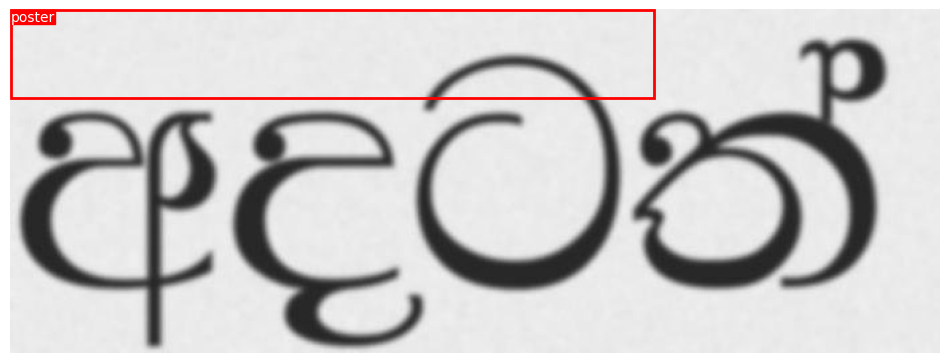

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

def visualize_model_vision(image, results, task_name):
    """
    Draws the model's detected regions on the image.
    """
    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(image)

    # Florence-2 returns coordinates in a specific dictionary format
    # Example: {'<CAPTION_TO_PHRASE_GROUNDING>': {'bboxes': [[x1, y1, x2, y2]], 'labels': ['label']}}
    data = results[task_name]

    # Scale coordinates: Florence-2 uses a 1000x1000 grid
    w, h = image.size

    if 'bboxes' in data:
        for bbox, label in zip(data['bboxes'], data['labels']):
            # Rescale normalized coordinates to pixel values
            x1, y1, x2, y2 = bbox
            x1, x2 = (x1 * w) / 1000, (x2 * w) / 1000
            y1, y2 = (y1 * h) / 1000, (y2 * h) / 1000

            # Create a rectangle patch
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor='r', facecolor='none')
            ax.add_patch(rect)
            plt.text(x1, y1, label, color='white', verticalalignment='top', bbox={'color': 'red', 'pad': 0})

    plt.axis('off')
    plt.show()

# --- RUNNING THE TEST ---
# Use Phrase Grounding to see what the model thinks "text" is
caption_prompt = "<CAPTION_TO_PHRASE_GROUNDING>"
od_prompt = "<OD>"
prompt = od_prompt

# And remove the 'text_input' part, as <OD> doesn't need it
inputs = processor(text=prompt, images=image, return_tensors="pt").to("cuda").to(torch.float16)

# for caption prompt
# text_input = "text" # We are asking: "Where is the text?"
# inputs = processor(text=text_input, images=image, return_tensors="pt").to("cuda").to(torch.float16)

generated_ids = model.generate(input_ids=inputs["input_ids"], pixel_values=inputs["pixel_values"], max_new_tokens=1024)
prediction = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]

# Parse and Plot
results = processor.post_process_generation(prediction, task=prompt, image_size=image.size)
visualize_model_vision(image, results, prompt)